#  案例实战：Qwen3大模型意图+槽位联合抽取

In [1]:
import os
import json
import torch
import peft
import transformers
import numpy as np
import pandas as pd
from datasets import Dataset
import matplotlib.pyplot as plt
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq

In [2]:
print(torch.__version__)
print(peft.__version__)
print(transformers.__version__)

2.7.0+cu128
0.17.1
4.53.1


In [3]:
# 指令微调的提示词（可调整）
PROMPT = """你是一个文本实体识别领域的专家，你需要从给定的句子中提取意图和实体. 请以指定的格式输出, 如 "音乐搜索-歌曲:千年等一回", "调高座椅温度-小数:0.27". 如果找不到任何意图和实体时, 输出"未知-无". """

In [4]:
def process_func(example):
    """
    将数据集进行预处理
    """
    MAX_LENGTH = 256 # 这个最大长度可以根据自己的数据来调整，可以先设置一个较大的数，tokenize完了之后再去统计一下token的长度分布
    input_ids, attention_mask, labels = [], [], []
    
    # 这里不能带思考，enable_thinking要关掉
    instruction = tokenizer(
        f"<|im_start|>system\n{PROMPT}<|im_end|>\n<|im_start|>user\n{example['input']}<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n",
        add_special_tokens=False,
    )
    response = tokenizer(f"{example['output']}", add_special_tokens=False)
    # 在末尾添加一个pad token id，代表文本结束
    input_ids = instruction["input_ids"] + response["input_ids"] + [tokenizer.pad_token_id]
    # mask都是1
    attention_mask = (
        instruction["attention_mask"] + response["attention_mask"] + [1]
    )
    # 把输入部分的tokens屏蔽掉，不计算loss，不能左移1位
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"] + [tokenizer.pad_token_id]

    # 按最大的上下文长度截断
    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
        
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}   


In [5]:
# 用modelscope 下载Qwen3-8B模型到本地目录下
# !modelscope download --model Qwen/Qwen3-8B --cache_dir="./"

# 加载模型权重
model_dir = "Qwen/Qwen3-8B" 
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(model_dir, torch_dtype=torch.bfloat16)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

In [6]:
print(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 4096)
    (layers): ModuleList(
      (0-35): 36 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (up_proj): Linear(in_features=4096, out_features=12288, bias=False)
          (down_proj): Linear(in_features=12288, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): Qwen3RMSNorm((4096,), eps=1e-06)
        (post_attention_layernorm): 

In [23]:
# 测试一下输入的格式是否正确
messages = [
    {"role": "system", "content": f"{PROMPT}"},
    {"role": "user", "content": "打开车窗"}
]
tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)

'<|im_start|>system\n你是一个文本实体识别领域的专家，你需要从给定的句子中提取意图和实体. 请以指定的格式输出, 如 "音乐搜索-歌曲:千年等一回", "调高座椅温度-小数:0.27". 如果找不到任何意图和实体时, 输出"未知-无". <|im_end|>\n<|im_start|>user\n打开车窗<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'

In [25]:
f"<|im_start|>system\n{PROMPT}<|im_end|>\n<|im_start|>user\n打开车窗<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n"

'<|im_start|>system\n你是一个文本实体识别领域的专家，你需要从给定的句子中提取意图和实体. 请以指定的格式输出, 如 "音乐搜索-歌曲:千年等一回", "调高座椅温度-小数:0.27". 如果找不到任何意图和实体时, 输出"未知-无". <|im_end|>\n<|im_start|>user\n打开车窗<|im_end|>\n<|im_start|>assistant\n<think>\n\n</think>\n\n'

In [7]:
# 加载处理数据集（这个数据是shuffle过后）
dataset_path = "data/raw_data.jsonl"

# 测试集+验证集的比例为5%，训练95%
test_val_ratio = 0.05
total_df = pd.read_json(dataset_path)

train_df = total_df[int(len(total_df) * test_val_ratio):]
test_val_df = total_df[:int(len(total_df) * test_val_ratio)]
# 验证集只用test_val_的20%
val_df = test_val_df[:int(len(test_val_df))//5]
test_df = test_val_df[int(len(test_val_df))//5:]
test_df.to_json('data/test_5k.jsonl', orient='records', force_ascii=False)

print("train size:", len(train_df))
print("eval size:", len(val_df))
print("test size:", len(test_df))

train size: 106689
eval size: 1123
test size: 4492


In [8]:
total_df

,input,output
0,没事退出导航,关闭导航-无
1,你型我想的是,未知-无
2,把油箱那几公里数清零,未知-无
3,前座通风能不能开到最大？,"调大座椅通风-位置:前排,强度:最强"
4,请在所有降190.123档风力,"降低空调风力-位置:全部,小数:190.123"
...,...,...
112299,我说拿好过来我们这边如果你打打牌了我上查到,未知-无
112300,感受一下把主驾驶和右后侧的风调调到最小吧,"设置空调风力-位置:主对角,强度:最小"
112301,上司,未知-无
112302,最后一步了之后又不适合这么麻点,未知-无


In [11]:
# 统计意图分布和slots分布
intents_map = {}
slots_map = {}
for output in total_df["output"]:
    intent, slots = output.split("-")
    if intent not in intents_map:
        intents_map[intent] = 0
    intents_map[intent] += 1
    slots = slots.split(",")
    for slot in slots:
        if ":" not in slot:
            continue
        slot_name, slot_value = slot.split(":")
        if slot_name not in slots_map:
            slots_map[slot_name] = 0
        slots_map[slot_name] += 1

In [15]:
for key, value in sorted(intents_map.items(), key=lambda x: -x[1]):
    print(key, value)

未知 32507
导航搜索 5673
音乐搜索 4201
设置座椅通风 2901
调高座椅温度 2890
调低座椅温度 2864
设置座椅按摩 2763
调大座椅通风 2761
设置空调温度 2749
电台搜索 2691
设置空调风力 2580
调低座椅通风 2456
关闭导航 2361
设置座椅温度 2203
调大音量 2141
设置氛围灯亮度 2100
添加途经点 2080
调高空调温度 2030
降低音量 1926
降低空调风力 1896
调高氛围灯亮度 1893
调高空调风力 1889
降低空调温度 1866
调低氛围灯亮度 1794
调低座椅按摩 1763
设置氛围灯颜色 1754
新闻搜索 1747
调大座椅按摩 1729
打开车窗 1380
打开播放器 1283
打开空调 1253
设置家地址 1215
关闭播放器 1143
设置公司地址 1065
设置音量 1025
查询湿度 1013
打开导航 1002
关闭空调 969
关闭车窗 876
查询风力 838
天气查询 514
打开天窗 323
关闭天窗 197


In [17]:
for key, value in sorted(slots_map.items(), key=lambda x: -x[1]):
    print(key, value)

位置 20647
强度 19857
POI 7951
正整数 7839
小数 4983
百分数 4447
音源 2202
媒体源 2182
歌曲 2020
颜色 1594
歌手 1517
主播名称 1058
节目名称 1033
城市 996
途经点 789
日期 690
节目类型 557
新闻地区 478
新闻人物 396
新闻类型 390
负数 356
专辑 233
门牌号 200
新闻关键字 200
歌曲流派 150
歌手2 136
电台关键词 114
歌曲主题 113
歌曲语言 112
中心点 102
交叉口 87
儿童歌曲 79
歌手地区 78
榜单 73
歌曲心情 68
歌曲年代 64
歌曲场景 57
综艺节目 30
电视剧 27
电影 9
歌曲关键字 8


In [ ]:
# 为什么要用这样的微调数据格式

"""意图：播放歌曲，歌手:周杰伦，歌曲:七里香

"播放歌曲-歌手:周杰伦,歌曲:七里香" ， 20
理由：
1.速度更快，json的长度比上面更长
2.格式锁定，格式失效的问题

output= '''{
    "intent": "播放歌曲",
    "slots": 
    {
        "歌手": "周杰伦",
        "歌曲": "七里香"
    }
}'''
"""

In [18]:
# 开始tokenize数据
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

train_dataset = train_ds.map(process_func, num_proc=16, remove_columns=train_ds.column_names)
val_dataset = val_ds.map(process_func, num_proc=16, remove_columns=val_ds.column_names)

Map (num_proc=16):   0%|          | 0/106689 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/1123 [00:00<?, ? examples/s]

In [19]:
train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 106689
})

In [8]:
# 定义LoRA微调参数
config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, # 生成式的模型
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"], # Attention + FFN
    inference_mode=False, # 训练模式
    r=8,                  # LoRA rank
    lora_alpha=32,        # LoRA alpha
    lora_dropout=0.1,     # Dropout比例，防止过拟合
)

model = get_peft_model(model, config)

In [9]:
# 模型训练的参数
args = TrainingArguments(
    output_dir="./output/lora_single_gpu",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,  # 总batch size=4*8=32
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=500,
    weight_decay=0.1,              # 权重衰减比例
    max_grad_norm=1.0,             # 梯度裁剪比例
    warmup_ratio=0.01,             # warmup比例
    optim="adamw_torch",           # 优化器适用adamw
    lr_scheduler_type="cosine",    # 学习率的衰减策略
    num_train_epochs=2,
    save_steps=500,
    save_total_limit=3,
    learning_rate=1e-4,
    label_names=["labels"]         # 指定peft模型的labels
)

In [13]:
# 开始训练
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True) # 和sft一样，用seq2seq collator
)

trainer.train()

Step,Training Loss,Validation Loss
500,0.059600,0.082358
1000,0.063500,0.057538
1500,0.049600,0.048619
2000,0.043300,0.042441
2500,0.033000,0.040774
3000,0.032400,0.033225
3500,0.020000,0.033933
4000,0.021000,0.029795
4500,0.026800,0.026202
5000,0.022600,0.025017


TrainOutput(global_step=6670, training_loss=0.06032882277788162, metrics={'train_runtime': 16024.2346, 'train_samples_per_second': 13.316, 'train_steps_per_second': 0.416, 'total_flos': 1.0699918940611768e+18, 'train_loss': 0.06032882277788162, 'epoch': 2.0})

# 画图

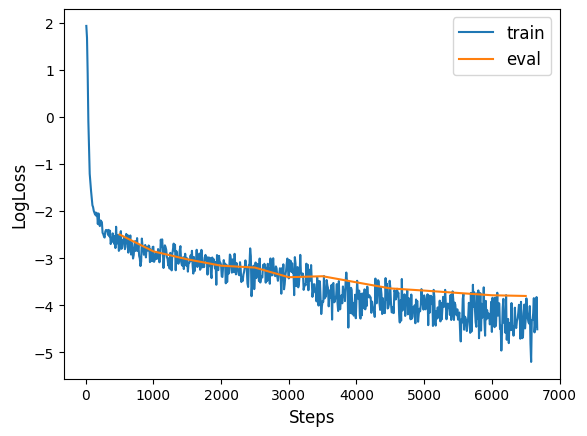

In [14]:
history = trainer.state.log_history
train_steps = [item["step"] for item in history if "loss" in item]
train_loss = [item["loss"] for item in history if "loss" in item]
eval_steps = [item["step"] for item in history if "eval_loss" in item]
eval_loss = [item["eval_loss"] for item in history if "eval_loss" in item]
train_log_loss = np.log(train_loss)
eval_log_loss = np.log(eval_loss)


plt.plot(train_steps, train_log_loss, label="train")
plt.plot(eval_steps, eval_log_loss, label="eval")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("LogLoss", fontsize=12)
plt.legend(fontsize=12)
plt.show()

# 预测代码

In [17]:
def predict(messages, model, tokenizer):
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    model_inputs = tokenizer([text], return_tensors="pt").to("cuda")

    generated_ids = model.generate(
        model_inputs.input_ids,
        max_new_tokens=128
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]     
    return response

In [20]:
# 用测试集的随机20条，测试模型
sample_test = test_df.sample(n=20)
for index, row in sample_test.iterrows():
    messages = [
        {"role": "system", "content": f"{PROMPT}"},
        {"role": "user", "content": f"{row['input']}"}
    ]
    response = predict(messages, model, tokenizer)
    messages.append({"role": "assistant", "content": f"{response}"})
    print(messages[1]['content'], "=>", messages[2]['content'])

帮我播放电台的每日选听 => 电台搜索-无
我想让风力达到二十三点九六。 => 调高空调风力-小数:23.96
当前的空气潮湿指数是多少 => 查询湿度-无
全车座椅需要散散热 => 调低座椅温度-位置:全部
成都市青白江区金童华庭1号门 => 未知-无
空调调到25 ℃ => 设置空调温度-正整数:25
寻找中文的音乐给我听 => 音乐搜索-歌曲语言:华语
请给我设置在那个设置在的地图啊 => 未知-无
音乐的音量开大一点 => 调大音量-音源:媒体
事无这人生啊 => 未知-无
想知道，成都的空气有多干燥 => 查询湿度-城市:成都
稍微提高最大度的座椅热度 => 调高座椅温度-强度:最大
风量给我调到27.7。 => 设置空调风力-小数:27.7
西湖街新 => 未知-无
发柯式呢 => 未知-无
让风力上升0.27 => 调高空调风力-小数:0.27
让主驾和右后的座椅按摩开到最弱。 => 设置座椅按摩-位置:主对角,强度:最低
快将音量适度降到10.9 => 设置音量-小数:10.9
就这个 => 未知-无
把座椅通风调到最小档吧 => 调低座椅通风-强度:最小
